In [1]:
!git clone https://github.com/solamar2/Brain-Tumor-MRI---DETR

fatal: destination path 'Brain-Tumor-MRI---DETR' already exists and is not an empty directory.


In [2]:
%cd /content/Brain-Tumor-MRI---DETR

/content/Brain-Tumor-MRI---DETR


In [3]:
from scripts.EDA import BrainTumorEDA
from scripts.segmentation import BrainMaskSimple
from scripts.preprocessing import BrainTumorDataset
from scripts.dataloader import BrainTumorDataLoader
import os
import random
from pathlib import Path

main_path = os.getcwd()
main_train_path= os.path.join(main_path, 'data/Train')

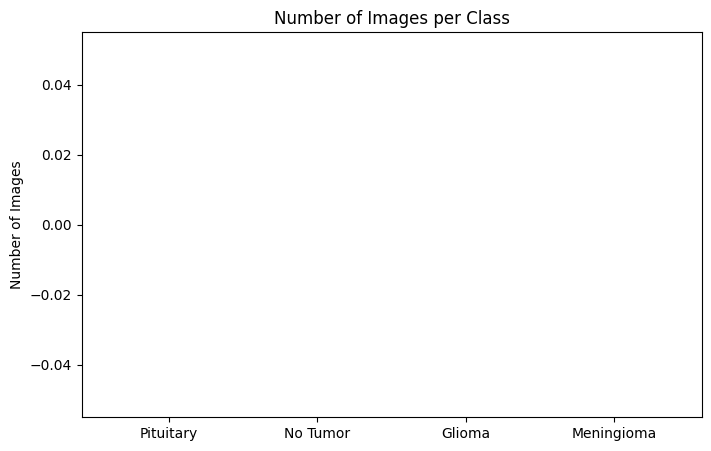

<Figure size 1000x800 with 0 Axes>

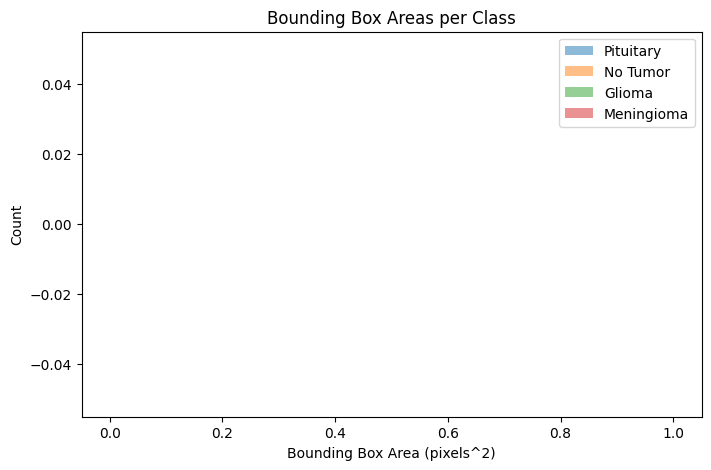

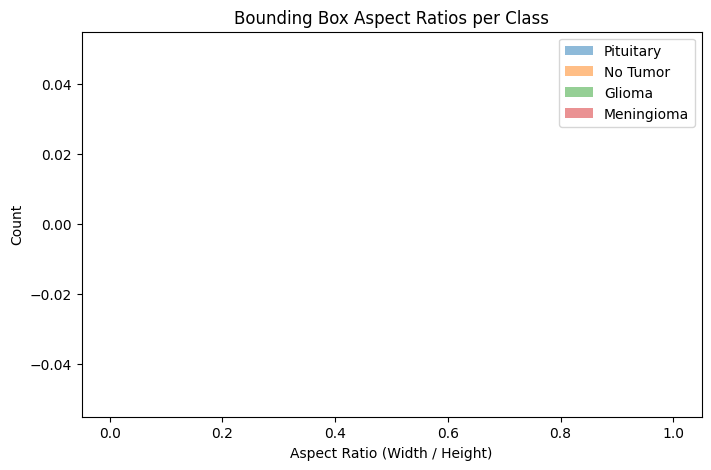

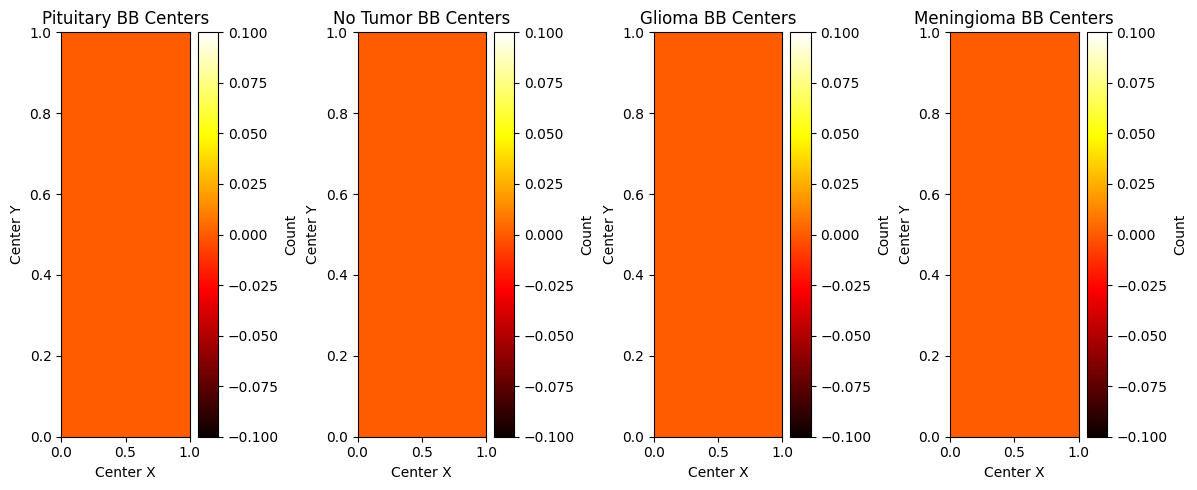

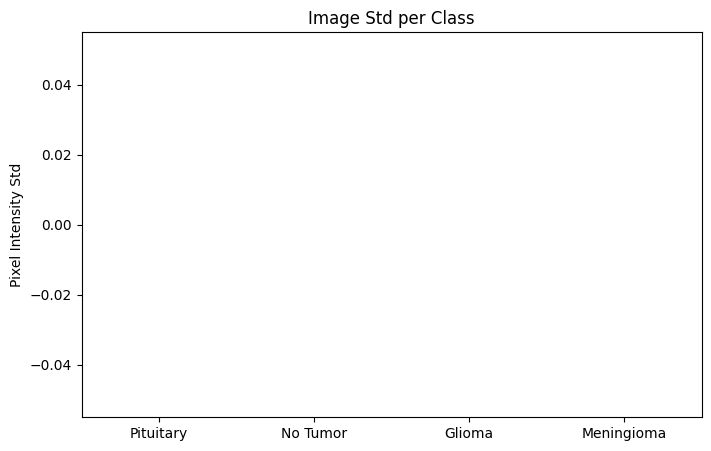

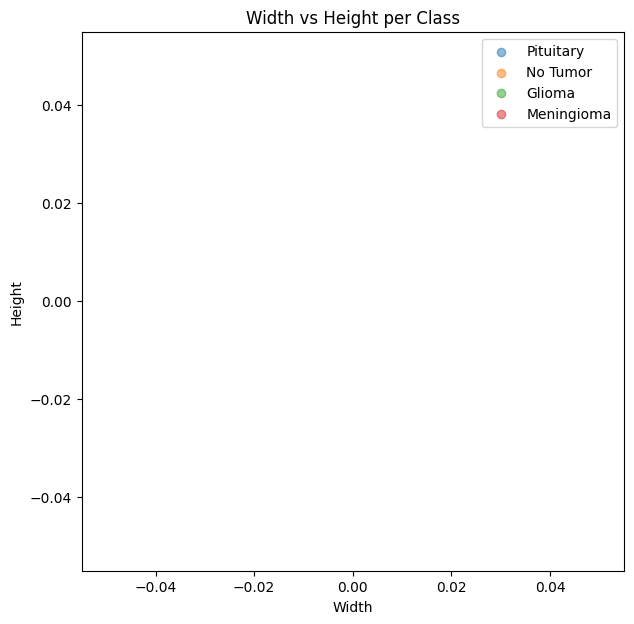

In [4]:
# ------------------------------
## 0. EDA:
eda = BrainTumorEDA(main_train_path)
eda.plot_class_counts_and_examples()
eda.plot_bb_analysis()
eda.plot_image_stats()


Masks saved: Pituitary
Masks saved: No Tumor
Masks saved: Glioma
Masks saved: Meningioma


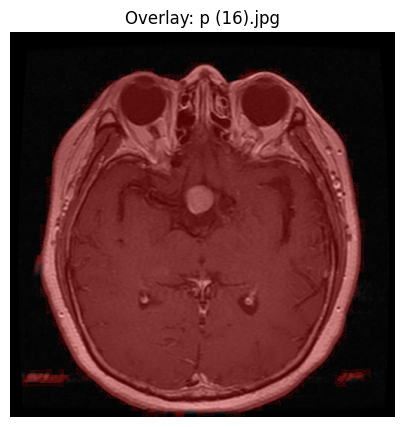

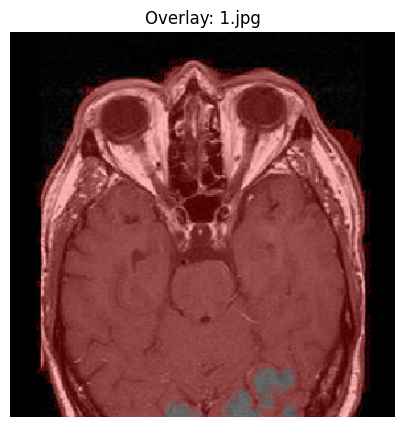

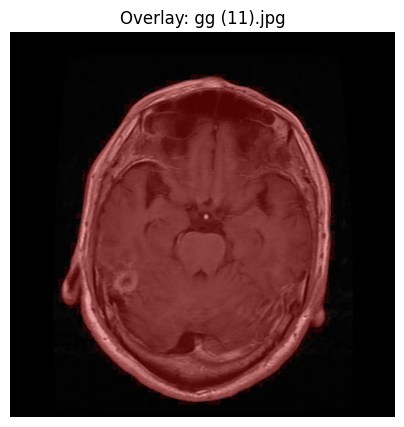

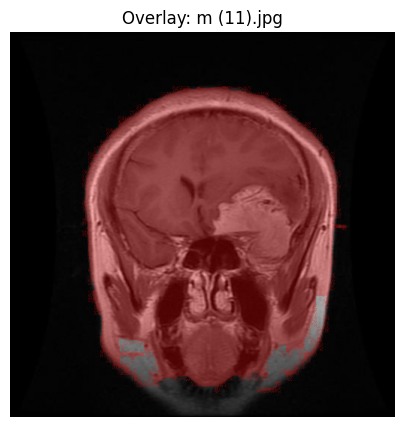

In [5]:
# ------------------------------
## 1. Segment brain vs background
# Collect class dirs that need segmentation

segmenter = BrainMaskSimple(train_dir=main_train_path)
segmenter.run()

# Random visualization (one image per class)
for cls_name in os.listdir(main_train_path):
    cls_dir = os.path.join(main_train_path, cls_name)
    images_dir = os.path.join(cls_dir, "images")
    masks_dir = os.path.join(cls_dir, "brain_masks")
    if not os.path.exists(images_dir) or not os.path.exists(masks_dir):
        continue

    img_file = random.choice([f for f in os.listdir(images_dir) if f.endswith(".jpg")])
    img_path = os.path.join(images_dir, img_file)
    mask_path = os.path.join(masks_dir, img_file)
    segmenter.create_overlay(img_path, mask_path, alpha=0.3)

In [6]:
# ------------------------------
# Class to idx: (same to train and test)
class_names = sorted([d for d in os.listdir(main_train_path) if os.path.isdir(os.path.join(main_train_path, d))])
class_to_idx = {cls_name: idx for idx, cls_name in enumerate(class_names)}

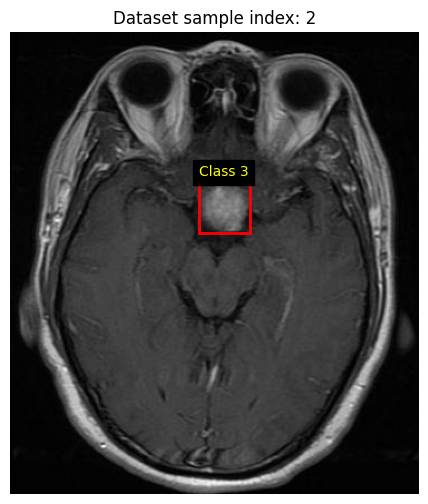

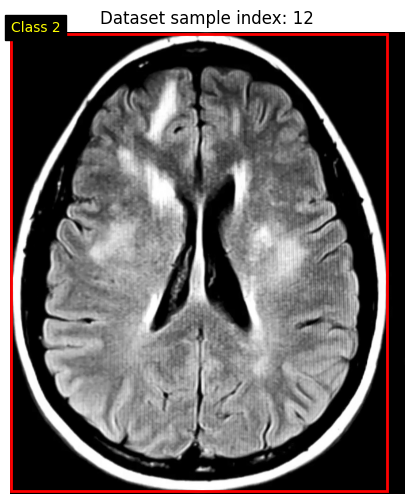

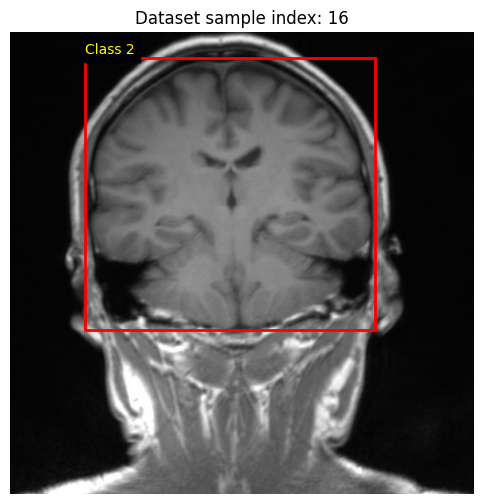

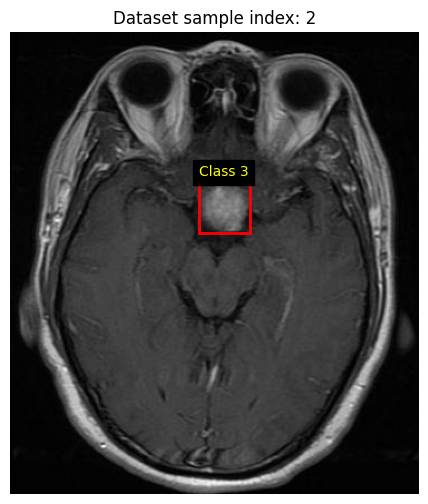

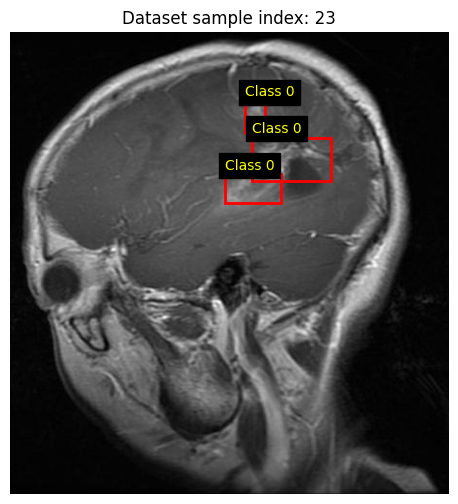

In [7]:
# ------------------------------
## 2. Pre process the data
traindataset = BrainTumorDataset(main_train_path, class_to_idx, image_size=(256, 256),augment=False)
for i in range (0,5):
    traindataset.visualize_sample()

In [8]:
# ------------------------------
## 3. Dataloader
loader_builder = BrainTumorDataLoader(traindataset, class_to_idx, batch_size=8, weighted_sampling=True)
train_loader = loader_builder.get_loader()